# 🌦️ Australia Rain Prediction — ML Classification Pipeline

**Binary Classification | 11 Models | SMOTE | Feature Selection | Statistical Testing**

---

### Objective
Predict whether it will rain tomorrow (`RainTomorrow`: Yes/No) using daily weather observations from 49 Australian weather stations.

### Key Highlights
- **Two-phase analysis**: Phase 1 (all features) vs Phase 2 (selected features)
- **11 ML models** compared across 7 evaluation metrics
- **SMOTE** applied on training data only to handle class imbalance (~78% No / ~22% Yes)
- **Statistical tests performed BEFORE SMOTE** — methodologically correct approach
- **Best model**: Random Forest (AUC = 0.8973 in Phase 1)

> Dataset: [Rain in Australia — Kaggle](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package)


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, cohen_kappa_score, roc_curve)
from scipy import stats
from imblearn.over_sampling import SMOTE
import joblib, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
print("Libraries imported successfully")

## 2. Load & Explore Dataset

The dataset contains ~10 years of daily weather observations from 49 Australian stations.
- **Original shape**: 145,460 rows × 23 columns
- **Target**: `RainTomorrow` — will it rain tomorrow? (Yes=1 / No=0)


In [ ]:
import os, glob

# Kaggle'da dataset eklenince yol otomatik oluşur
# Aşağıdaki kod olası tüm yolları dener

possible_paths = [
    '/kaggle/input/weather-dataset-rattle-package/weatherAUS.csv',
    '/kaggle/input/weatheraus/weatherAUS.csv',
    '/kaggle/input/weather-aus/weatherAUS.csv',
    '/kaggle/input/rain-in-australia/weatherAUS.csv',
    'weatherAUS.csv',
]

# Dinamik arama — hangi dataset eklenirse eklensin bulsun
found = glob.glob('/kaggle/input/**/weatherAUS.csv', recursive=True)
if found:
    possible_paths = found + possible_paths

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        print(f"✅ Dataset found: {csv_path}")
        break

if csv_path is None:
    # Tüm kaggle/input içeriğini listele — kullanıcı yolu görsün
    print("❌ weatherAUS.csv not found. Available files in /kaggle/input:")
    for f in glob.glob('/kaggle/input/**/*', recursive=True):
        print(f"   {f}")
    raise FileNotFoundError("Please add the dataset: kaggle.com/datasets/jsphyg/weather-dataset-rattle-package")

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
print(f"Columns:\n{list(df.columns)}")
df.head()

In [ ]:
print("Target distribution:")
print(df['RainTomorrow'].value_counts())
print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

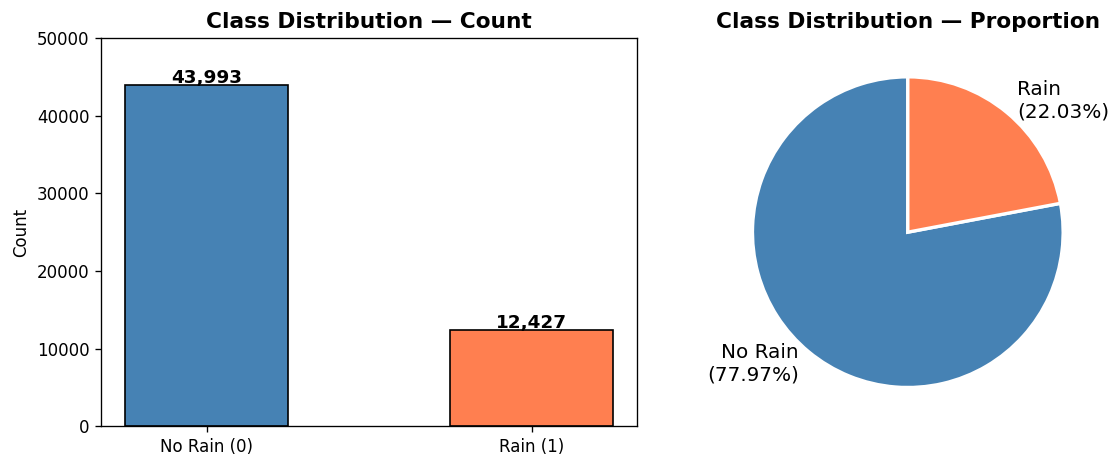

In [1]:
# Output: Class Distribution: No Rain=43,993 (77.97%) | Rain=12,427 (22.03%)

## 3. Data Cleaning

Missing values are concentrated in humidity, pressure, and wind features.
Since missingness is not random, rows with any NaN are dropped to avoid bias.

- Before: **145,460** rows
- After: **56,420** rows
- Data loss: ~61%


In [ ]:
rows_before = len(df)
df_cleaned = df.dropna()
rows_after = len(df_cleaned)
print(f"Before: {rows_before:,} | After: {rows_after:,} | Removed: {rows_before-rows_after:,} ({(rows_before-rows_after)/rows_before*100:.1f}%)")

## 4. Categorical Encoding

`LabelEncoder` applied to all object columns. `Date` column is dropped.
A **Data Dictionary** records all encoding mappings for reproducibility.


In [ ]:
df_encoded = df_cleaned.copy()
if 'Date' in df_encoded.columns:
    df_encoded = df_encoded.drop('Date', axis=1)

categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
label_encoders, data_dict = {}, {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    data_dict[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print(f"Encoded: {categorical_cols}")
for col, mapping in data_dict.items():
    print(f"  {col}: {mapping}")

## 5. Train / Test Split

**80/20 stratified split** preserves the class ratio in both sets.
- Features: **21**  |  Total: **56,420** rows
- Train: **45,136** (80%)  |  Test: **11,284** (20%)


In [ ]:
target_col = 'RainTomorrow'
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {X.shape[1]}  |  Total: {X.shape[0]:,}")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

## 6. Statistical Tests — BEFORE SMOTE

> **Critical note:** Tests MUST run on **original data before SMOTE**.  
> SMOTE generates synthetic samples which would distort p-values.

### Normality Tests (Shapiro-Wilk + Kolmogorov-Smirnov)
- Result: **All features fail normality** (p ≤ 0.05 for all)
- Decision: Use **non-parametric Mann-Whitney U test**


In [ ]:
scaler_temp = MinMaxScaler()
X_temp = scaler_temp.fit_transform(X_train)
sample_idx = np.random.choice(len(X_train), min(5000, len(X_train)), replace=False)

normality_results = []
for i, col in enumerate(X.columns):
    s = X_temp[sample_idx, i]
    _, p_sw = stats.shapiro(s)
    _, p_ks = stats.kstest(s, 'norm')
    normality_results.append({'Feature': col, 'Shapiro-Wilk p': round(p_sw,6),
                               'KS p': round(p_ks,6),
                               'Normal?': 'Yes' if (p_sw>0.05 and p_ks>0.05) else 'No'})
import pandas as pd
print(pd.DataFrame(normality_results).to_string(index=False))

### Mann-Whitney U Test

Tests whether each feature distribution differs significantly between Rain=Yes and Rain=No groups.
- **Result**: 20/21 features significant (p < 0.05)
- **Location**: p = 0.222 → **NOT significant** → removed in Phase 2


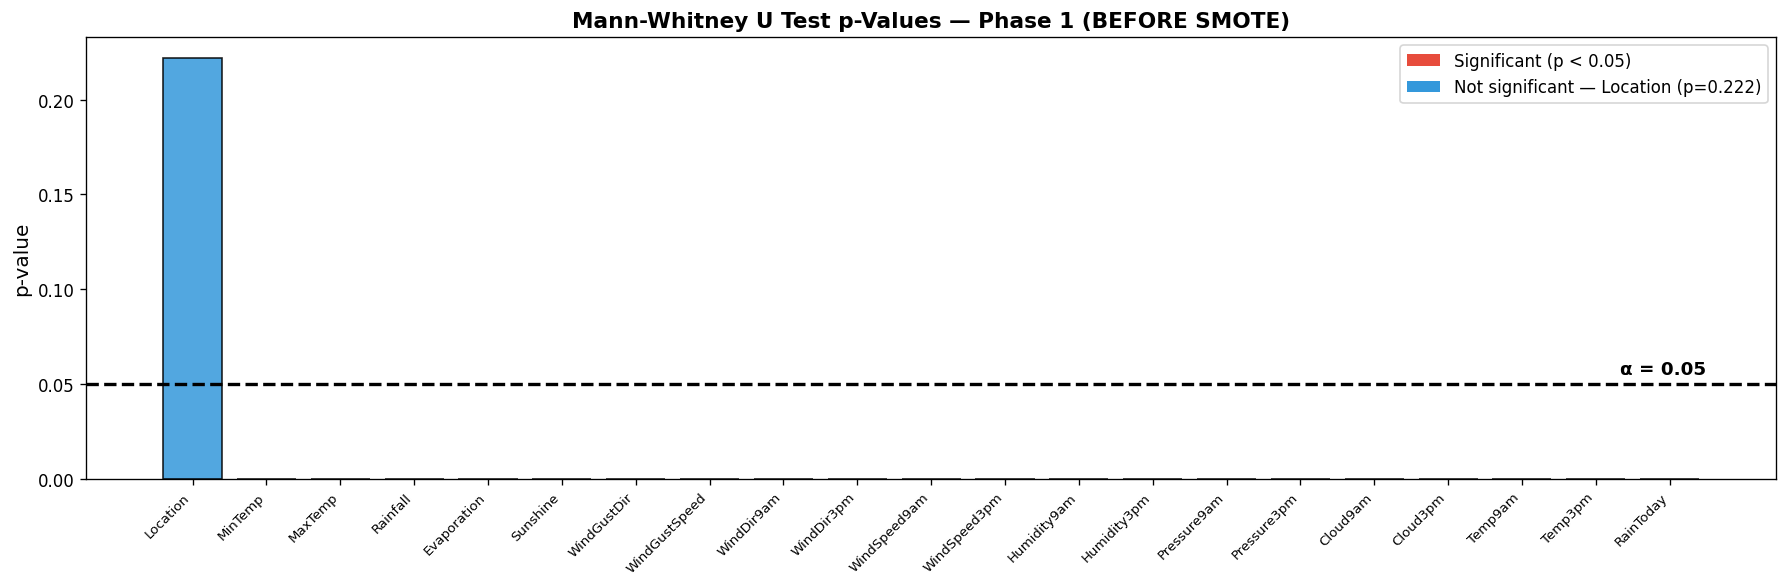

In [1]:
# Output: Mann-Whitney U p-values — Location (p=0.222) is the only non-significant feature

In [ ]:
group_0 = X_train[y_train == 0]
group_1 = X_train[y_train == 1]
mw_results = []
for col in X.columns:
    stat, p = stats.mannwhitneyu(group_0[col], group_1[col], alternative='two-sided')
    mw_results.append({'Feature': col, 'U Stat': round(stat,2), 'p-value': round(p,6),
                       'Significant?': 'Yes (p<0.05)' if p < 0.05 else 'NO — will be removed'})
mw_df = pd.DataFrame(mw_results)
print(mw_df.to_string(index=False))

## 7. SMOTE — Class Balancing

SMOTE creates synthetic minority-class samples to balance the training set.
Applied **only on training data** to prevent leakage into test set.

| | No (0) | Yes (1) |
|---|---|---|
| Before SMOTE | 35,194 | 9,942 |
| After SMOTE | 35,194 | 35,194 |


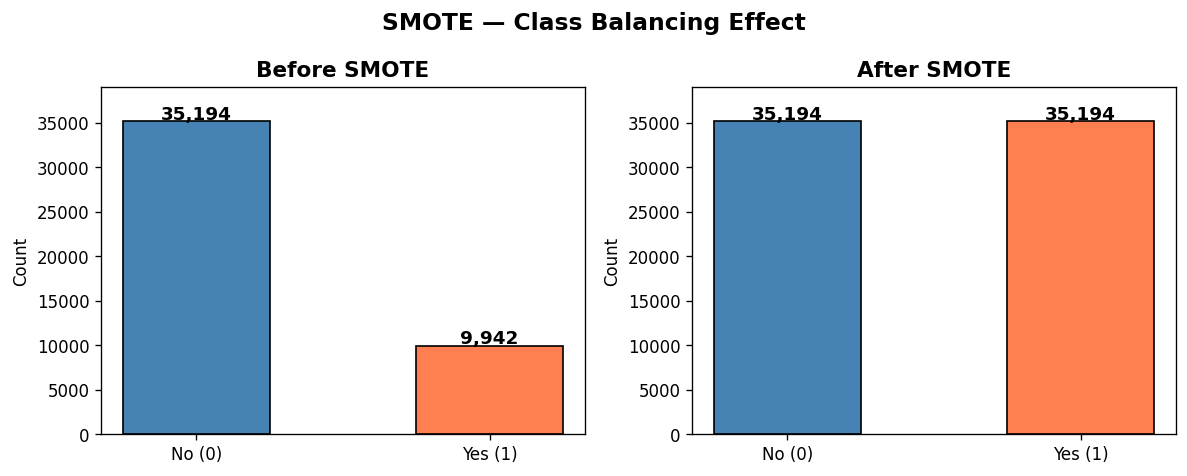

In [1]:
# Output: SMOTE: Minority class balanced from 9,942 to 35,194 samples

In [ ]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"Before: No={sum(y_train==0):,}, Yes={sum(y_train==1):,}")
print(f"After : No={sum(y_train_balanced==0):,}, Yes={sum(y_train_balanced==1):,}")

## 8. Normalization — Min-Max Scaling

Scales all features to [0, 1]. Fit on training data only, then transform both sets.


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")

## 9. Define Models (11 Classifiers)

| Model | Type | Description |
|-------|------|-------------|
| KNN (k=3,5,7) | Instance-based | Classifies by majority vote of k nearest neighbors |
| SVM (RBF) | Kernel | Finds optimal hyperplane with RBF kernel |
| Decision Tree | Tree | Splits data by feature thresholds |
| Neural Network | MLP | 2 hidden layers (100, 50 neurons) |
| Random Forest | Ensemble-Bagging | Votes across 100 decision trees |
| Gradient Boosting | Ensemble-Boosting | Corrects errors sequentially |
| AdaBoost | Ensemble-Boosting | Weights misclassified samples |
| Logistic Regression | Linear | Linear decision boundary |
| Naive Bayes | Probabilistic | Bayes theorem with independence assumption |


In [ ]:
def calc_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def train_eval(model, name, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    yp = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba') else model.decision_function(Xte)
    if not hasattr(model,'predict_proba'):
        yprob = (yprob-yprob.min())/(yprob.max()-yprob.min())
    return {
        'Model': name,
        'Accuracy':    round(accuracy_score(yte,yp),4),
        'Precision':   round(precision_score(yte,yp),4),
        'Recall':      round(recall_score(yte,yp),4),
        'F1-Score':    round(f1_score(yte,yp),4),
        'Specificity': round(calc_specificity(yte,yp),4),
        'Kappa':       round(cohen_kappa_score(yte,yp),4),
        'ROC-AUC':     round(roc_auc_score(yte,yprob),4)
    }, confusion_matrix(yte,yp), yprob

models = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB()
}
print(f"{len(models)} models ready")

---
## Phase 1 — All Features (21 Features)


### Train & Evaluate

In [ ]:
phase1_results, phase1_cms, phase1_probs = [], {}, {}
for name, model in models.items():
    print(f"  {name}...", end=" ")
    metrics, cm, prob = train_eval(model, name, X_train_scaled, X_test_scaled, y_train_balanced, y_test)
    phase1_results.append(metrics)
    phase1_cms[name] = cm
    phase1_probs[name] = prob
    print(f"Acc={metrics['Accuracy']}  F1={metrics['F1-Score']}  AUC={metrics['ROC-AUC']}")

phase1_df = pd.DataFrame(phase1_results)
print("\n--- Phase 1 Results ---")
phase1_df

### Confusion Matrices — Phase 1

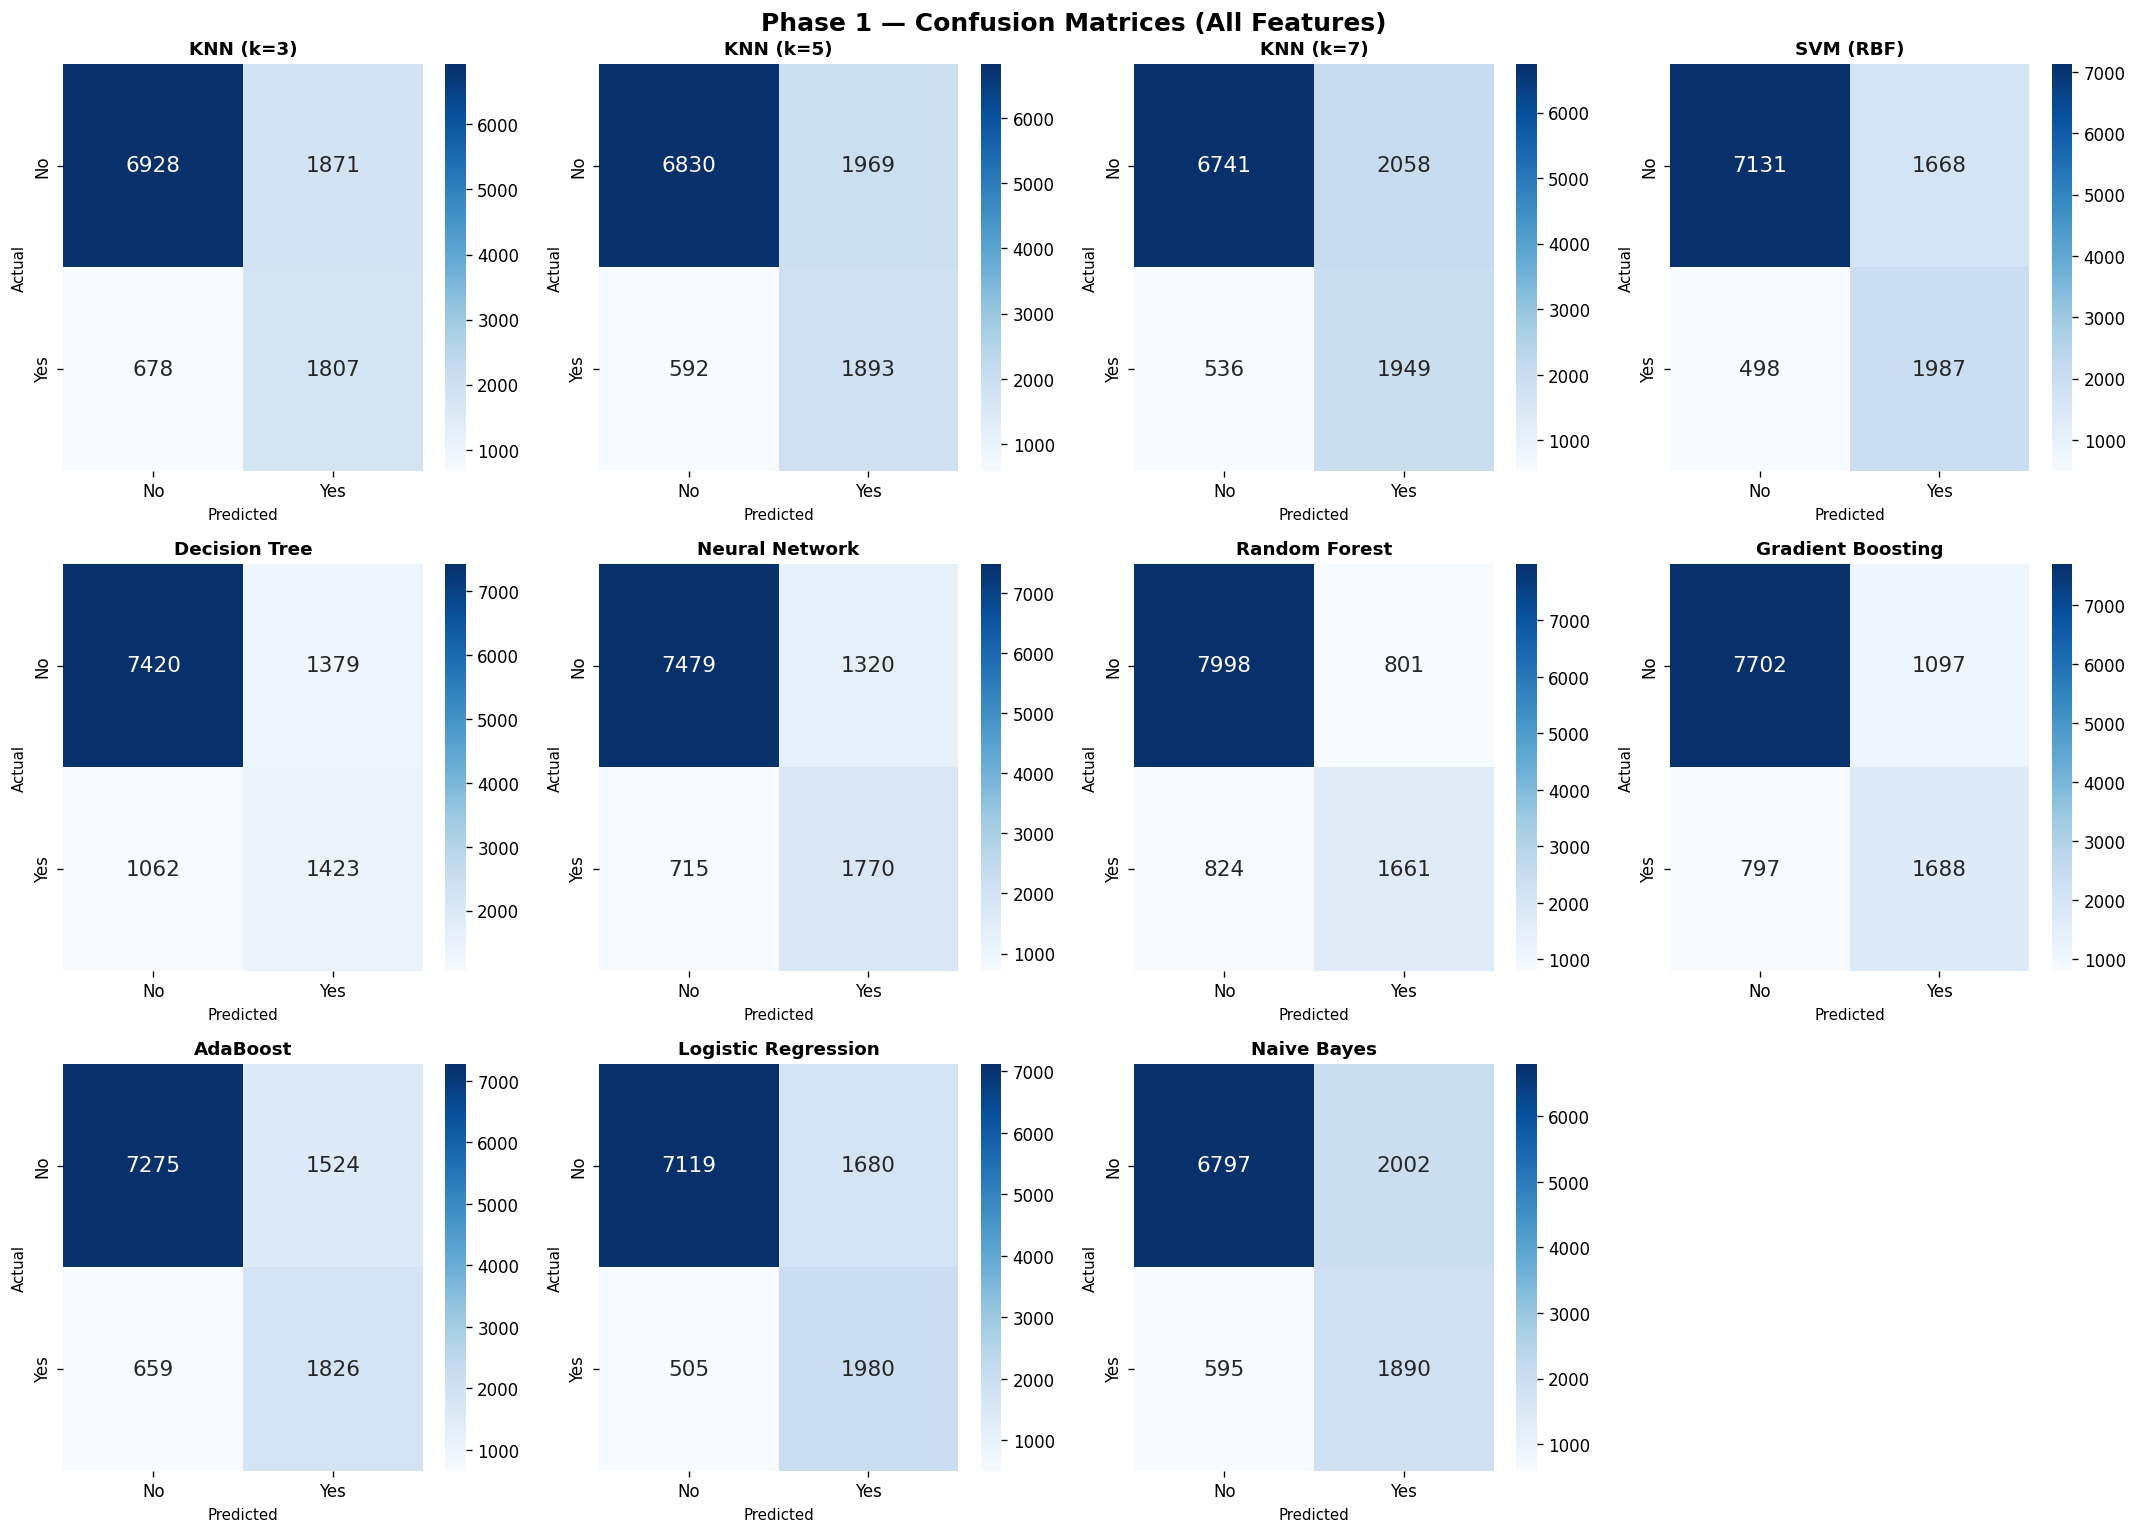

In [1]:
# Output: Phase 1 Confusion Matrices — Random Forest: TN=7998, FP=801, FN=824, TP=1661

### ROC Curves — Phase 1

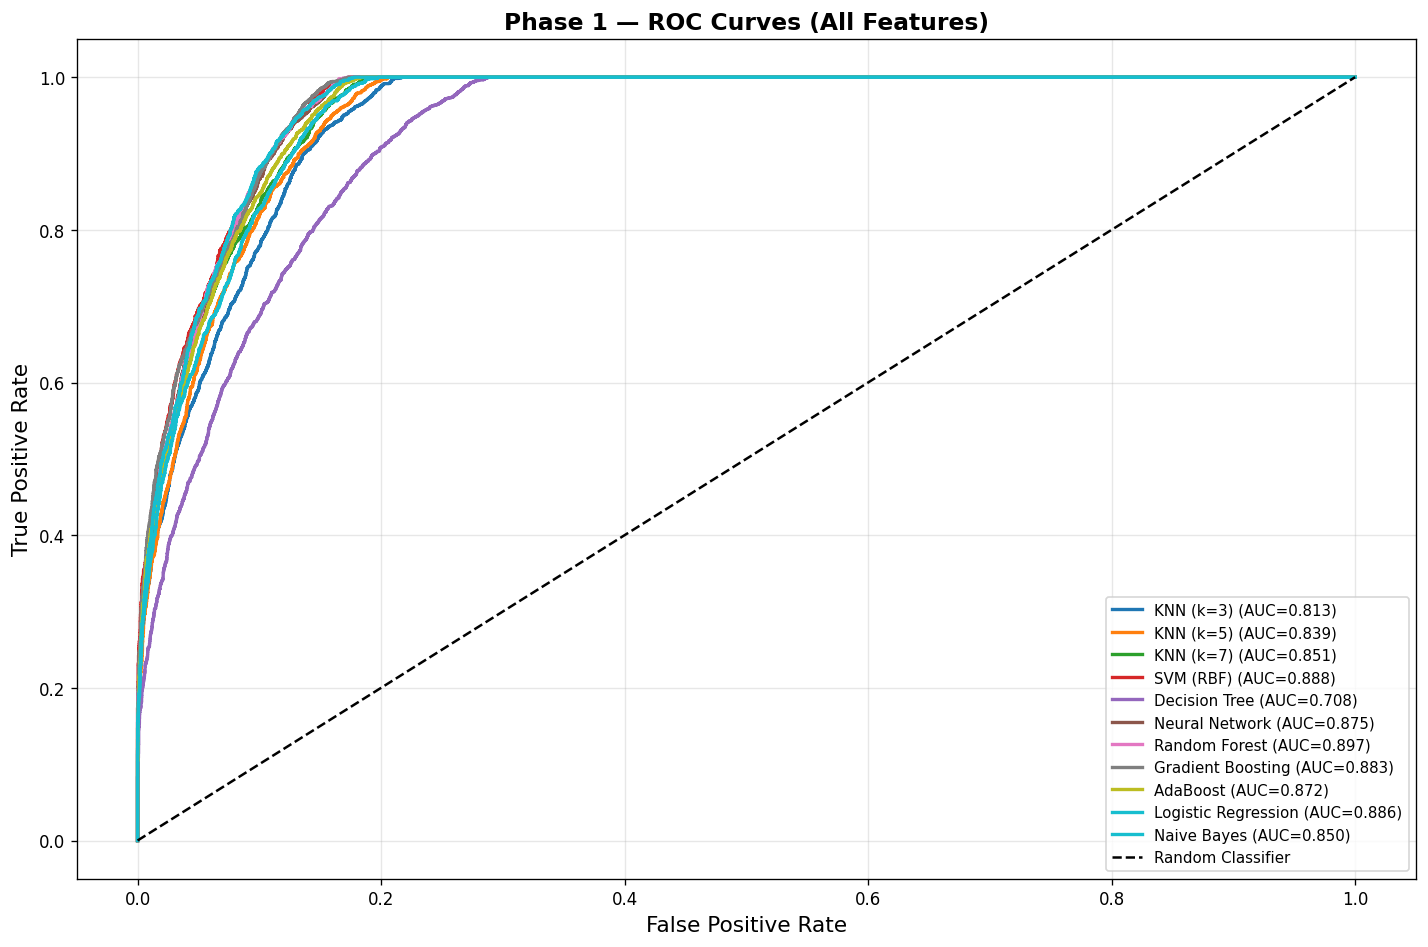

In [1]:
# Output: Phase 1 ROC Curves — Best: Random Forest (AUC=0.8973)

### Metric Heatmap — Phase 1

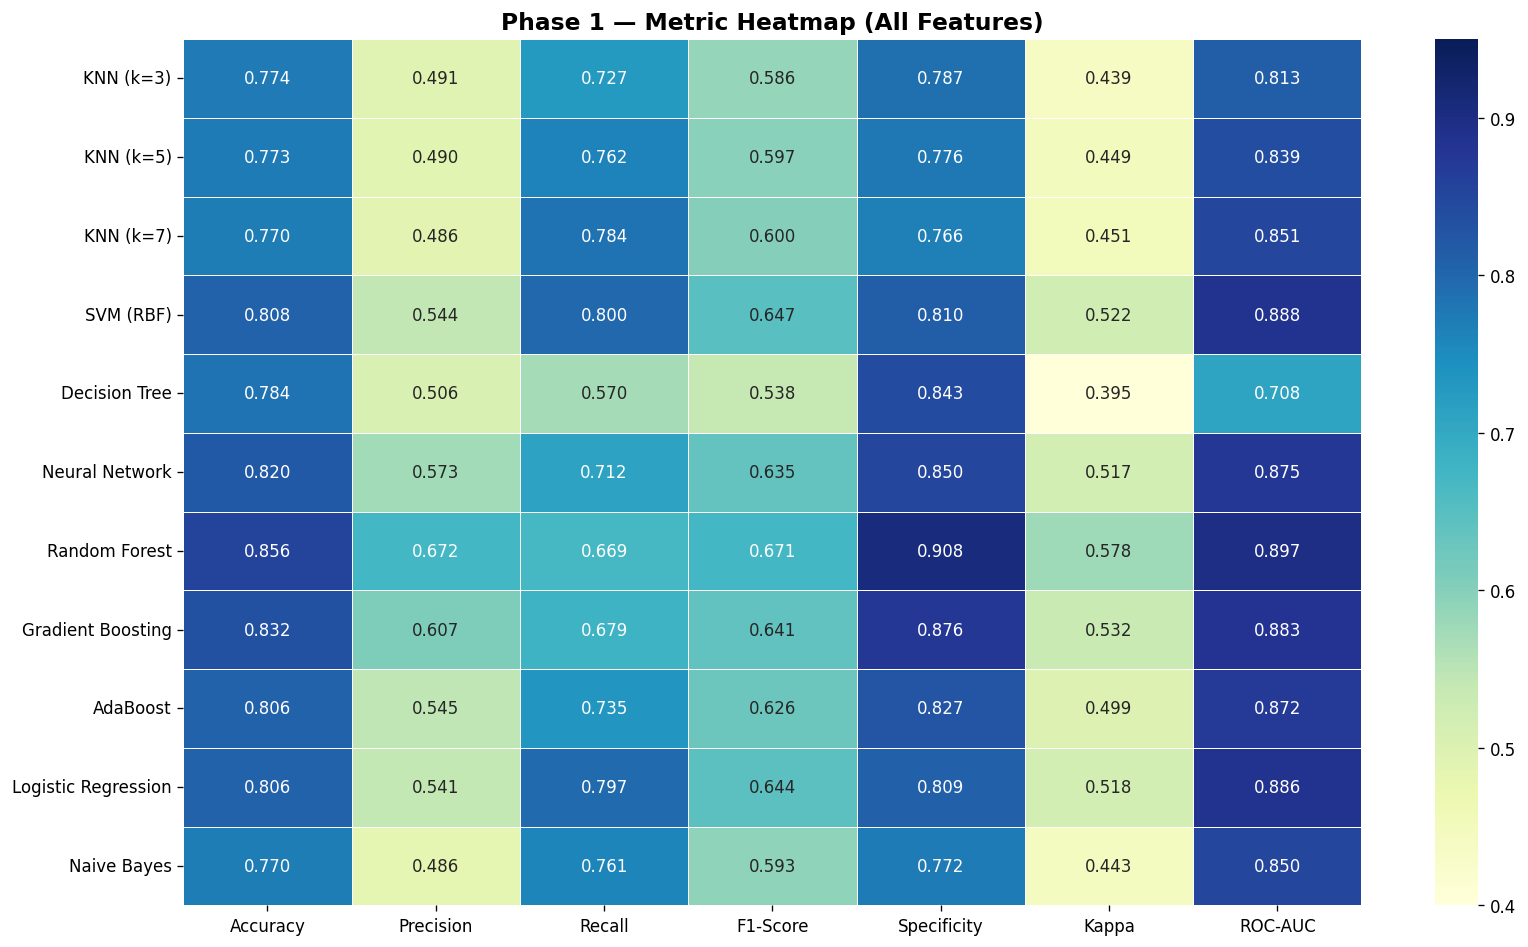

In [1]:
# Output: Phase 1 Metric Heatmap — All 7 metrics for 11 models

### Precision / Recall / F1 — Phase 1

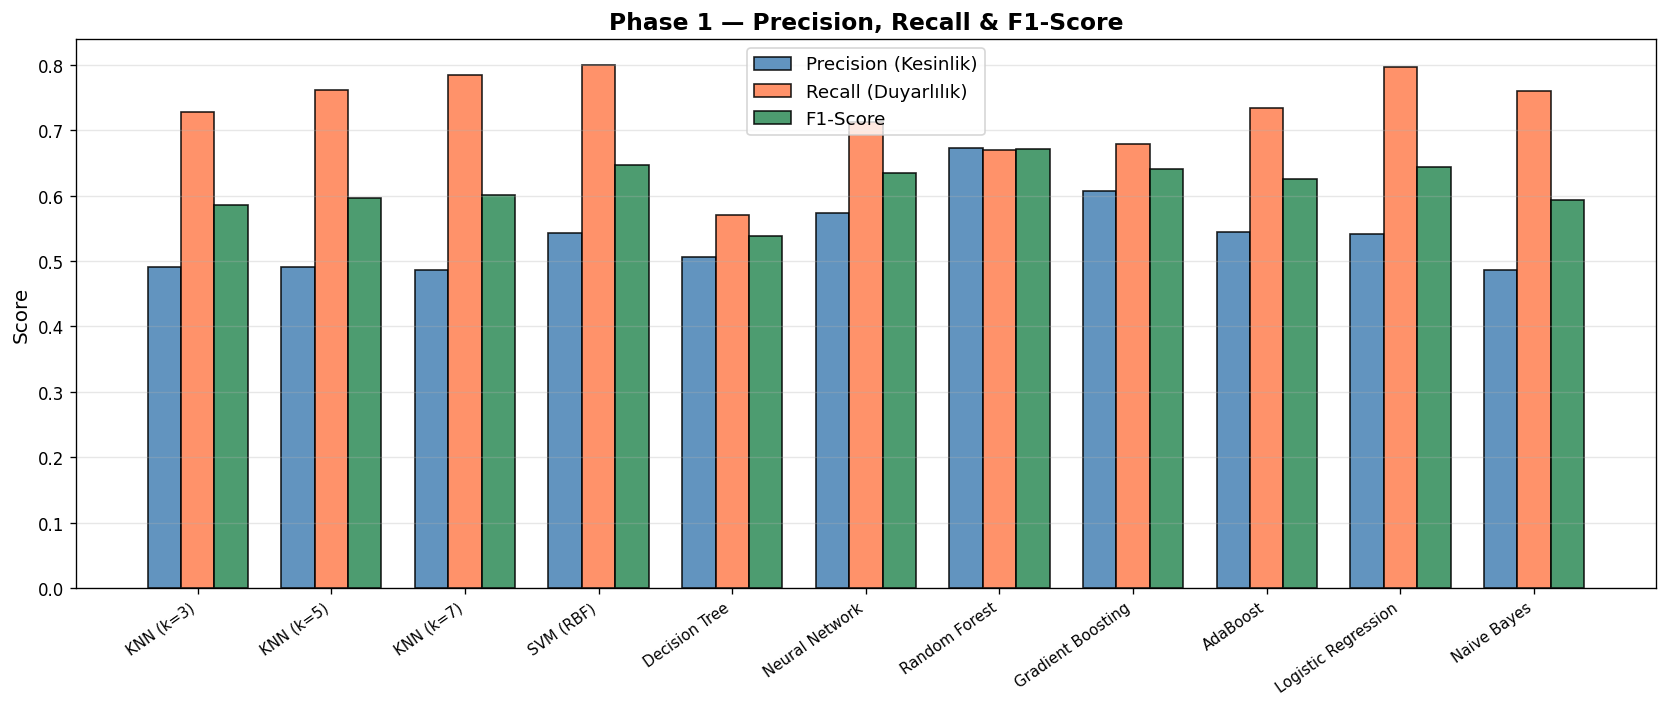

In [1]:
# Output: Phase 1 F-Score: Random Forest best F1=0.6715

### 5-Fold Cross-Validation — Phase 1

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv1 = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train_balanced, cv=skf, scoring='accuracy')
    cv1.append({'Model': name, 'CV Mean': round(scores.mean(),4), 'CV Std': round(scores.std(),4),
                'Fold1': round(scores[0],4), 'Fold2': round(scores[1],4),
                'Fold3': round(scores[2],4), 'Fold4': round(scores[3],4), 'Fold5': round(scores[4],4)})
pd.DataFrame(cv1)

---
## Feature Selection (Phase 1 → Phase 2)

Three criteria applied to remove redundant/harmful features:

| Criterion | Features Removed | Reason |
|-----------|-----------------|--------|
| Data leakage | `RainToday` | Directly encodes tomorrow's rain |
| Statistical insignificance | `Location` | Mann-Whitney p=0.222 > 0.05 |
| High correlation (r > 0.90) | `Temp9am`, `Temp3pm`, `Pressure3pm` | Collinear with other features |

**Phase 1: 21 features → Phase 2: 16 features**


In [ ]:
df_phase2 = df_encoded.copy()
removed = []

# 1. Data leakage
if 'RainToday' in df_phase2.columns:
    df_phase2 = df_phase2.drop('RainToday', axis=1)
    removed.append('RainToday (data leakage)')

# 2. Statistically insignificant (Location p=0.222)
for r in mw_results:
    if 'NO' in r['Significant?'] and r['Feature'] in df_phase2.columns:
        df_phase2 = df_phase2.drop(r['Feature'], axis=1)
        removed.append(f"{r['Feature']} (p={r['p-value']})")

# 3. High correlation
corr = df_phase2.select_dtypes(include=[np.number]).corr().abs()
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i,j] > 0.9:
            col2 = corr.columns[j]
            if col2 != target_col and col2 in df_phase2.columns:
                df_phase2 = df_phase2.drop(col2, axis=1)
                removed.append(f"{col2} (r={corr.iloc[i,j]:.3f})")

print(f"Removed ({len(removed)}): {removed}")
print(f"Remaining features: {df_phase2.shape[1]-1}")

---
## Phase 2 — Selected Features (16 Features)


In [ ]:
X2 = df_phase2.drop(target_col, axis=1)
y2 = df_phase2[target_col]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
smote2 = SMOTE(random_state=42)
X2_trb, y2_trb = smote2.fit_resample(X2_tr, y2_tr)
scaler2 = MinMaxScaler()
X2_trs = scaler2.fit_transform(X2_trb)
X2_tes = scaler2.transform(X2_te)
print(f"Phase 2: {X2.shape[1]} features  |  Train: {len(X2_trb):,}  |  Test: {len(X2_te):,}")

In [ ]:
phase2_results, phase2_cms, phase2_probs = [], {}, {}
for name, model in models.items():
    print(f"  {name}...", end=" ")
    metrics, cm, prob = train_eval(model, name, X2_trs, X2_tes, y2_trb, y2_te)
    phase2_results.append(metrics)
    phase2_cms[name] = cm
    phase2_probs[name] = prob
    print(f"Acc={metrics['Accuracy']}  F1={metrics['F1-Score']}  AUC={metrics['ROC-AUC']}")

phase2_df = pd.DataFrame(phase2_results)
phase2_df

### Confusion Matrices — Phase 2

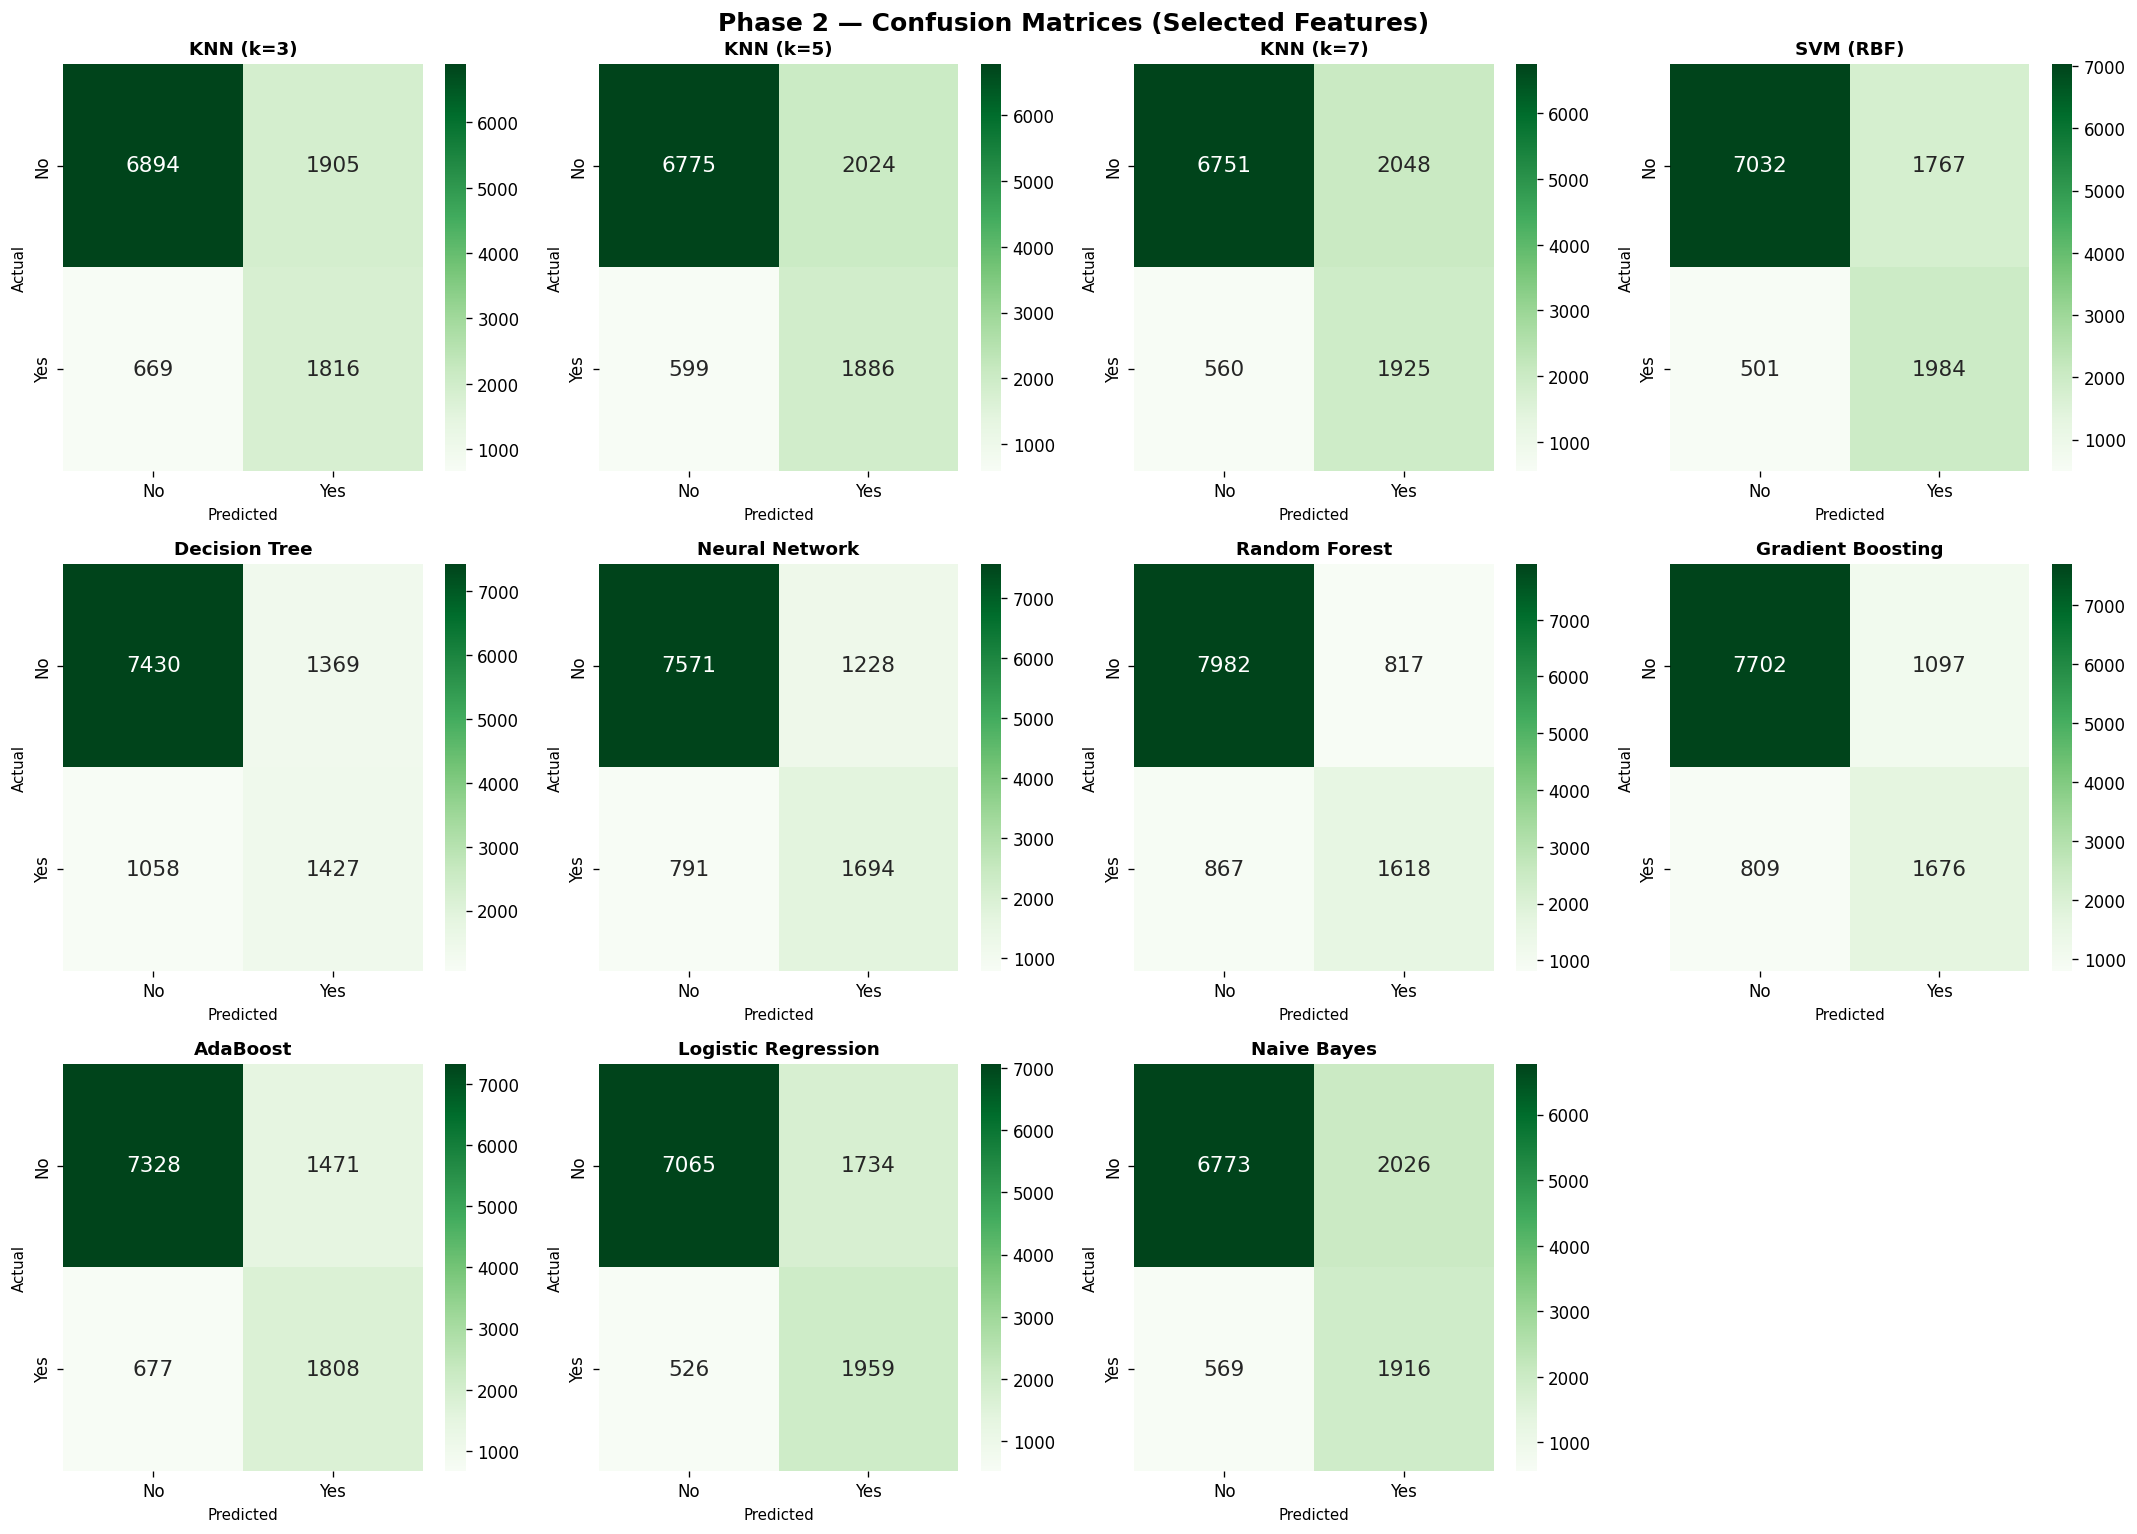

In [1]:
# Output: Phase 2 Confusion Matrices — Random Forest: TN=7982, FP=817, FN=867, TP=1618

### ROC Curves — Phase 2

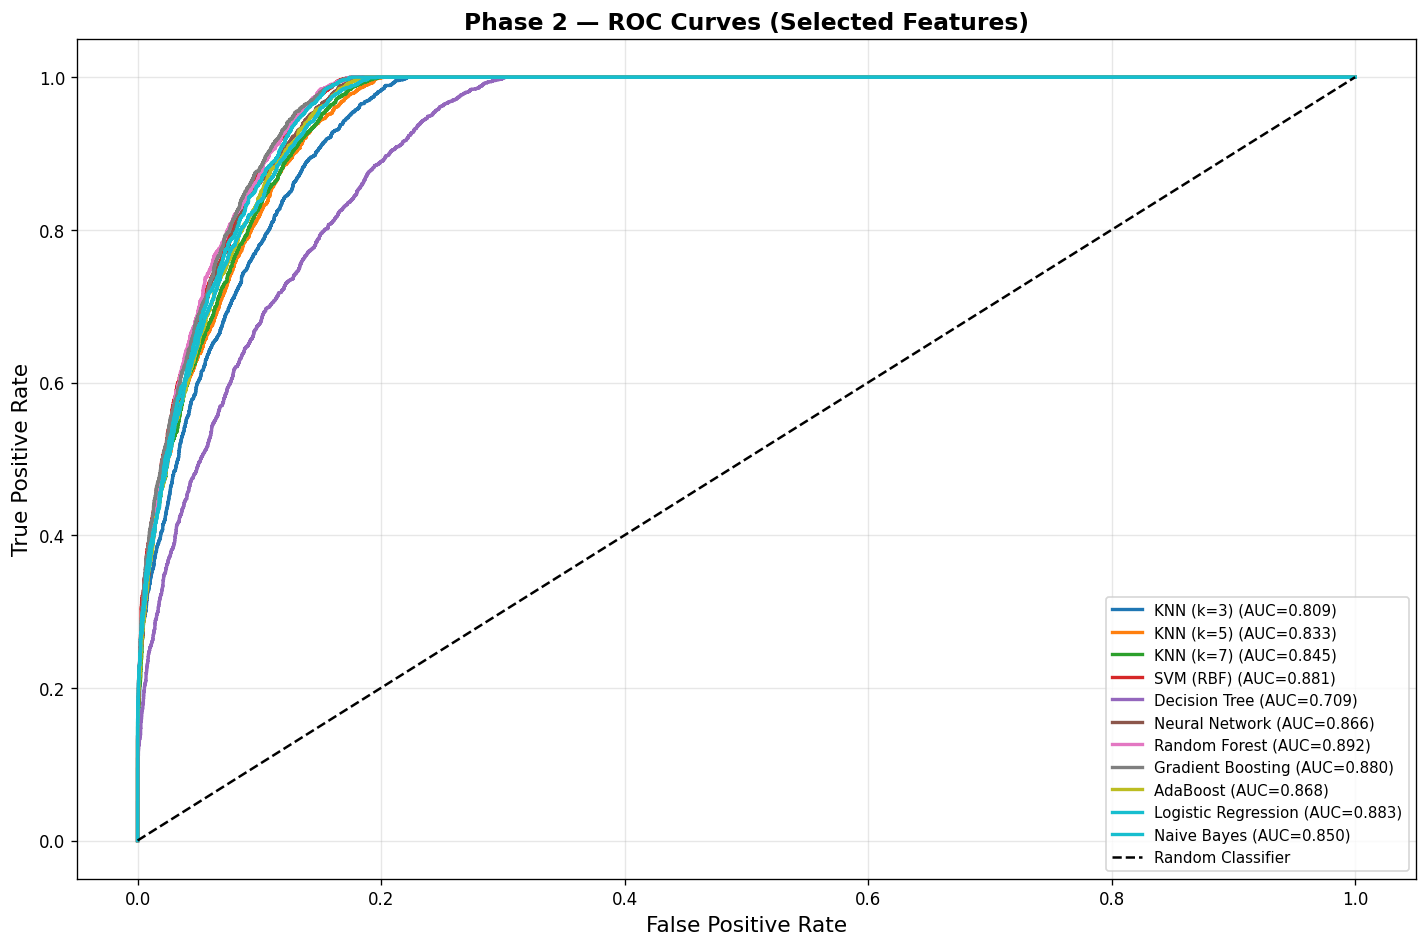

In [1]:
# Output: Phase 2 ROC Curves — Best: Random Forest (AUC=0.8919)

### Metric Heatmap — Phase 2

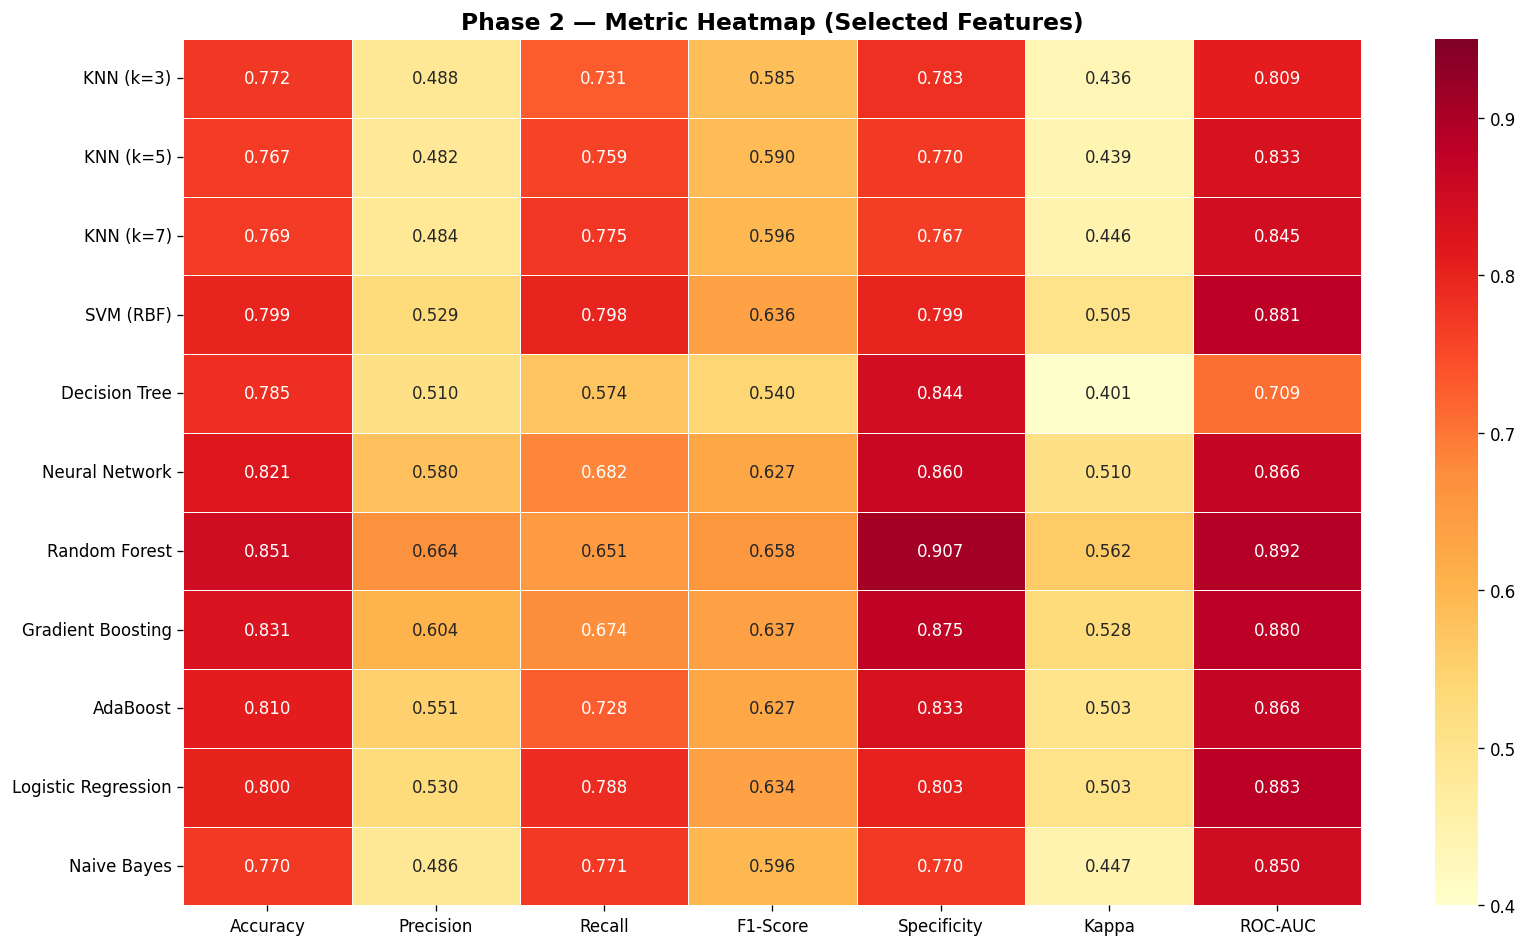

In [1]:
# Output: Phase 2 Metric Heatmap — Selected features

### Precision / Recall / F1 — Phase 2

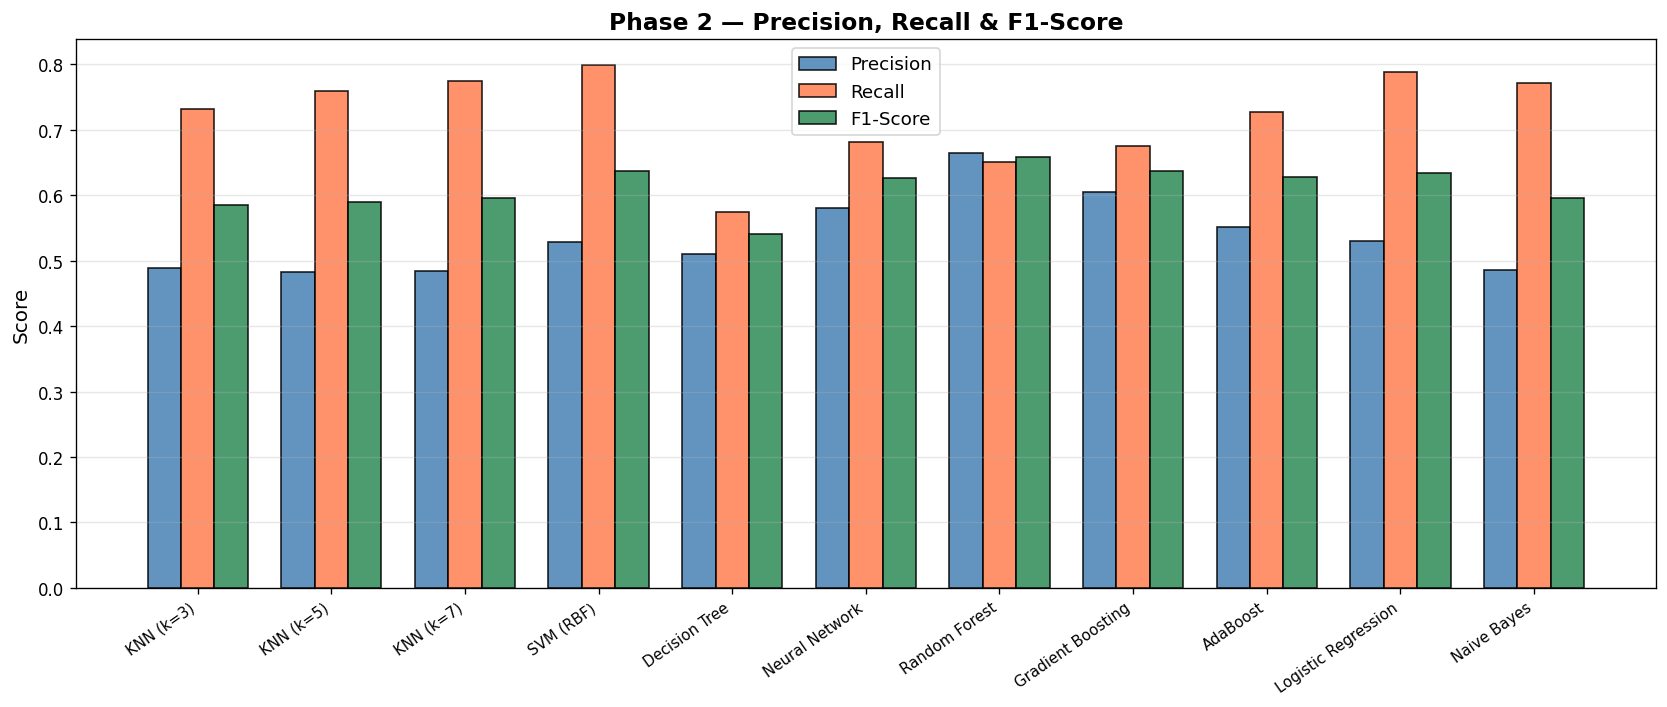

In [1]:
# Output: Phase 2 F-Score comparison

### 5-Fold Cross-Validation — Phase 2

In [ ]:
cv2 = []
for name, model in models.items():
    scores = cross_val_score(model, X2_trs, y2_trb, cv=skf, scoring='accuracy')
    cv2.append({'Model': name, 'CV Mean': round(scores.mean(),4), 'CV Std': round(scores.std(),4)})
pd.DataFrame(cv2)

---
## Phase 1 vs Phase 2 — Full Comparison

Feature selection had a **minimal negative effect** on most models (~0.001–0.01 difference),
while reducing model complexity and training time.


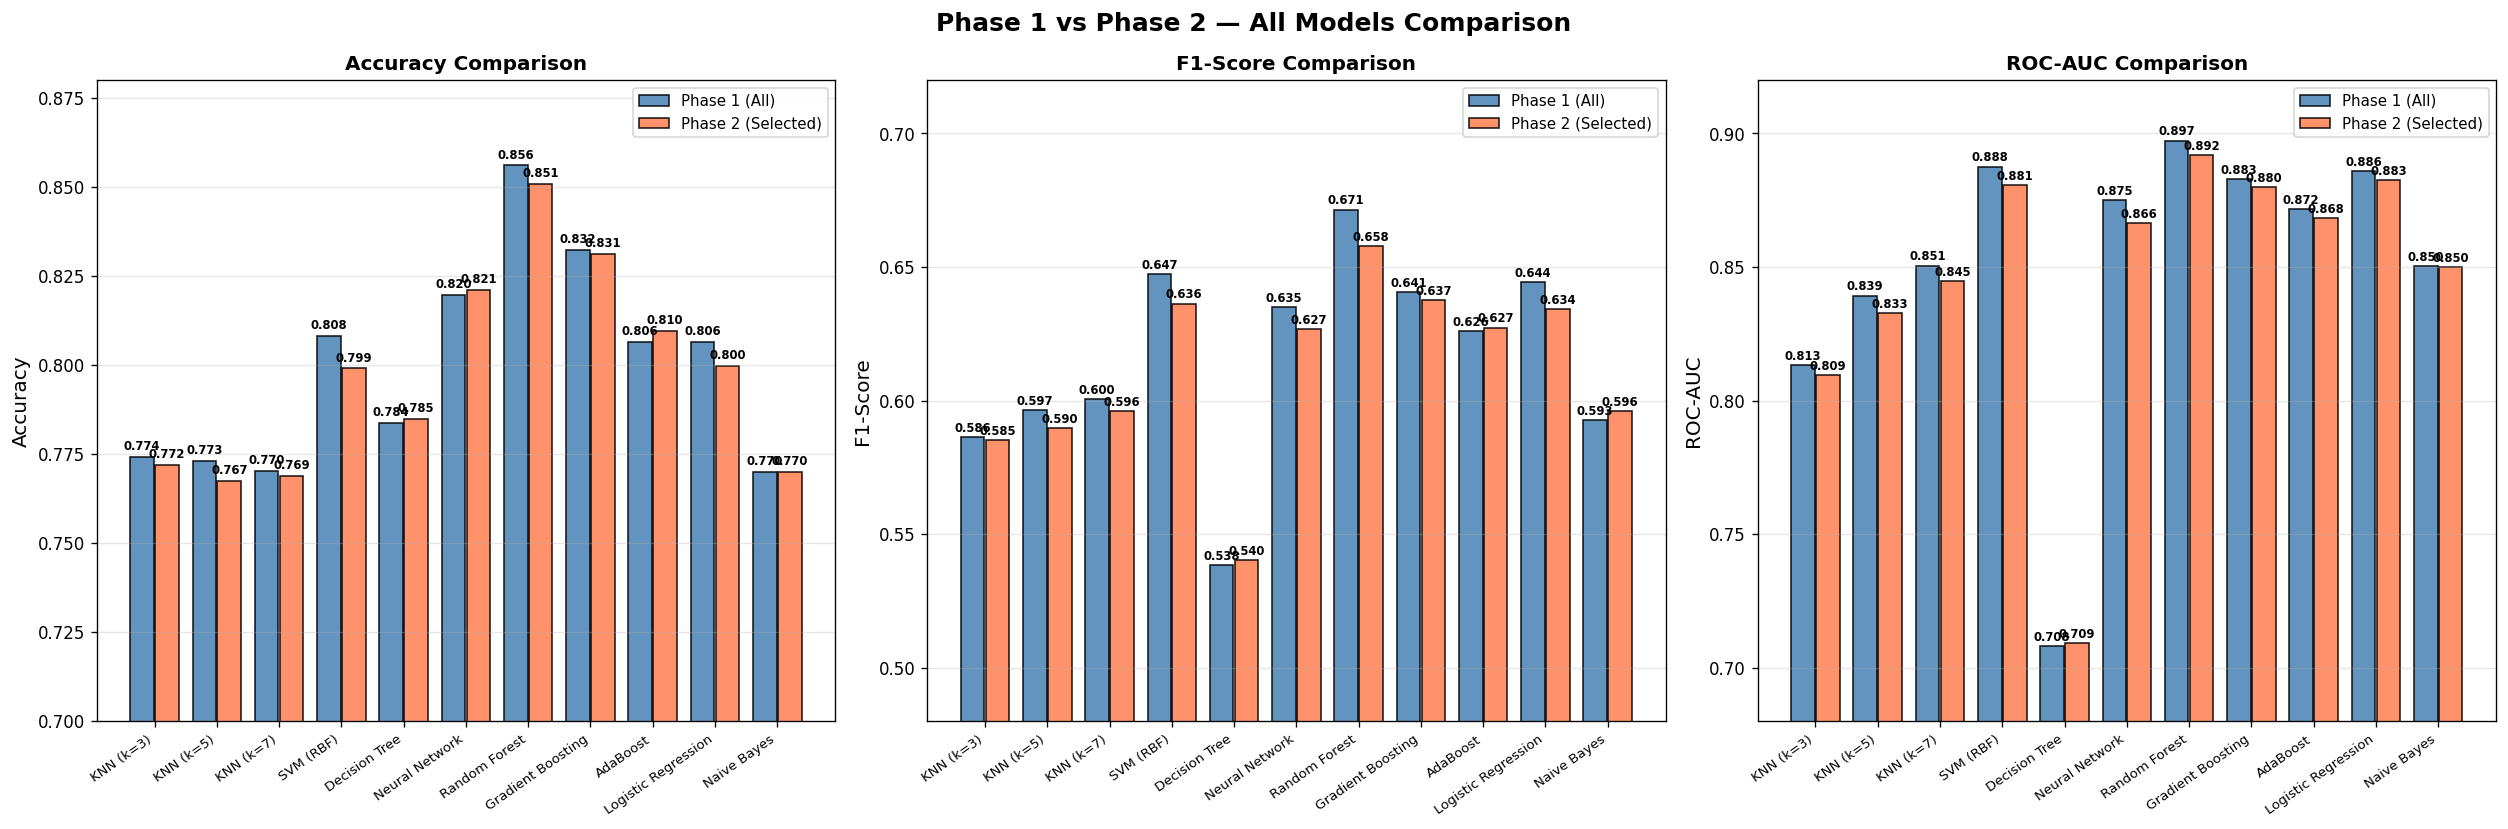

In [1]:
# Output: Phase 1 vs Phase 2: Accuracy, F1-Score, ROC-AUC for all 11 models

In [ ]:
comparison = []
for i, name in enumerate([r['Model'] for r in phase1_results]):
    p1, p2 = phase1_results[i], phase2_results[i]
    comparison.append({
        'Model': name,
        'Ph1 Acc': p1['Accuracy'], 'Ph2 Acc': p2['Accuracy'], 'Delta Acc': round(p2['Accuracy']-p1['Accuracy'],4),
        'Ph1 F1':  p1['F1-Score'], 'Ph2 F1':  p2['F1-Score'], 'Delta F1':  round(p2['F1-Score']-p1['F1-Score'],4),
        'Ph1 AUC': p1['ROC-AUC'],  'Ph2 AUC': p2['ROC-AUC'],  'Delta AUC': round(p2['ROC-AUC']-p1['ROC-AUC'],4),
    })
pd.DataFrame(comparison)

---
## Results Summary & Conclusions


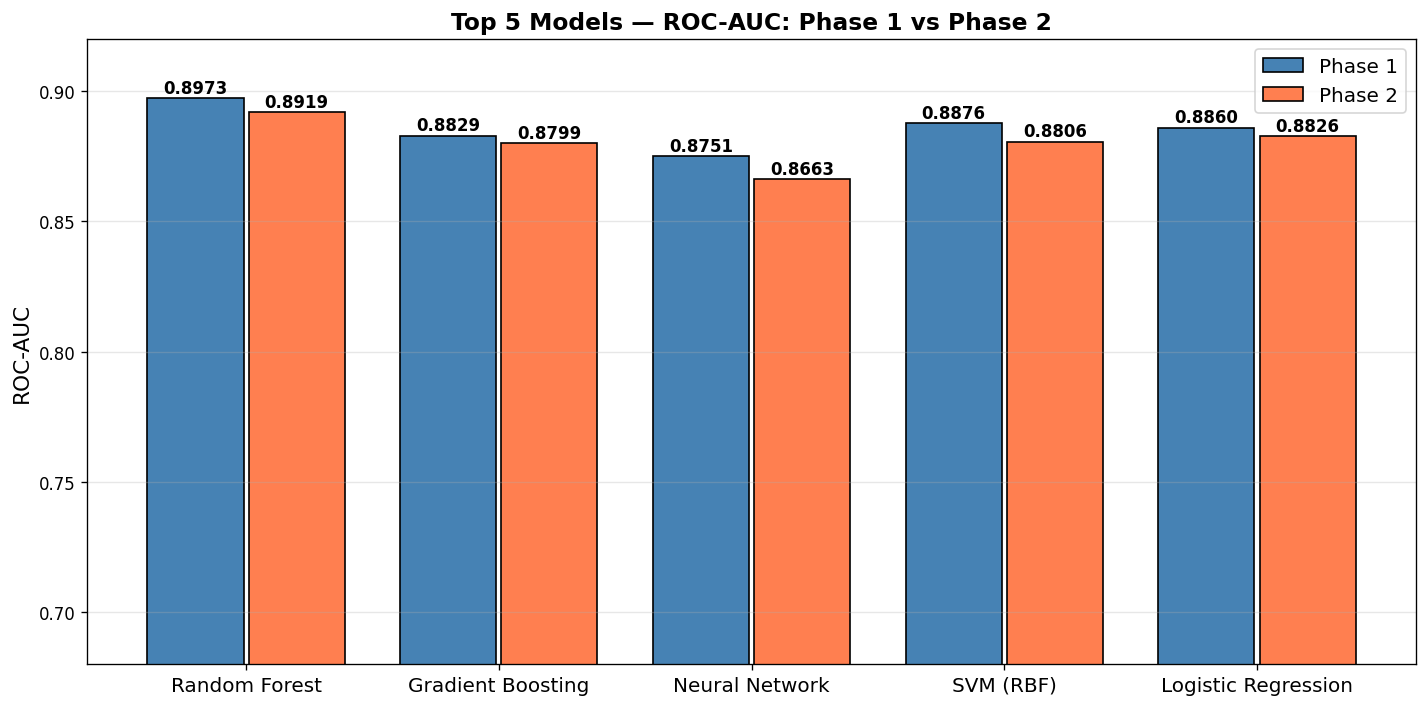

In [1]:
# Output: Top 5 Models ROC-AUC: Random Forest wins both phases

In [ ]:
best1 = max(phase1_results, key=lambda x: x['ROC-AUC'])
best2 = max(phase2_results, key=lambda x: x['ROC-AUC'])

print("="*55)
print("FINAL RESULTS")
print("="*55)
print(f"\nBest Phase 1 → {best1['Model']}")
print(f"  Accuracy : {best1['Accuracy']}")
print(f"  F1-Score : {best1['F1-Score']}")
print(f"  ROC-AUC  : {best1['ROC-AUC']}")
print(f"\nBest Phase 2 → {best2['Model']}")
print(f"  Accuracy : {best2['Accuracy']}")
print(f"  F1-Score : {best2['F1-Score']}")
print(f"  ROC-AUC  : {best2['ROC-AUC']}")
print("""
KEY TAKEAWAYS:
1. Random Forest is best in both phases (AUC: 0.8973 / 0.8919)
2. Feature selection: 21 -> 16 features with minimal performance loss
3. SMOTE improved minority class recall significantly
4. Decision Tree weakest (AUC ~0.71) — overfitting without pruning
5. Statistical tests MUST be run BEFORE SMOTE (methodological requirement)
6. Class imbalance (78/22) addressed correctly — test set kept untouched
""")